# 我使用了什么库？

In [136]:
# 需要导入的库

import random
import numpy as np
from PIL import Image

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler, SubsetRandomSampler
from torchvision.transforms.v2 import Compose, ToTensor, Normalize, ToPILImage, RandomHorizontalFlip, Resize, ToImage, ToDtype

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

from data_generation.image_classification import generate_dataset
from stepbystep.v0 import StepByStep
from plots.chapter4 import *


# 然后，我要干什么？

还是继续研究分类问题，但这次的问题是图像分类，所以还是先要**生成数据**

问题定义: 预测图像属于哪个类,判断图像的中的线是否为对角线？

# 图像分类

## 图像生成

图像信息: 300张图像,每个图像5x5像素

标签定义: 对象线图像是正类,否则是负类


结合代码:

**Q**: 如何创建随机图像?


[0 1 1]


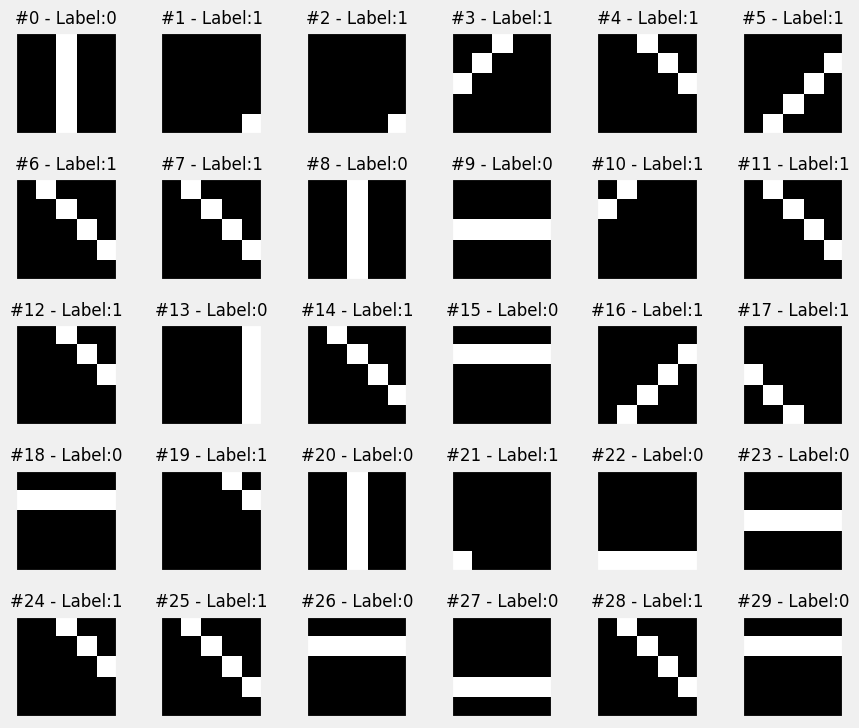

In [137]:
# 图像数据生成

# img大小,n_images是图像数量,seed是种子
images,labels = generate_dataset(img_size=5,n_images=300,binary=True,seed=13)

# 标签的结构
print(labels[:3])

# 图像绘制
fig = plot_images(images,labels,n_plot=30)

## 图像格式

**Q**: 在这里，图像是如何表示的？

结合代码:

**Q**: `np.stack`的作用是什么？对向量产生了什么影响？

**Q**: `np`操作中的`axis`究竟是怎么算的？(Tips:数括号,按括号顺序)

**Q**: 解释代码做了什么？

In [138]:
# 程序4-1: axix的用法
print(np.array([
    [[1,2,3],[4,5,6],[7,8,9]],
    [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]]).shape)
print(np.stack([
    [[1,2,3],[4,5,6],[7,8,9]],
    [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]], axis=2))
print(np.stack([
    [[1,2,3],[4,5,6],[7,8,9]],
    [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]], axis=2).shape)

(2, 3, 3)
[[[ 1 -1]
  [ 2 -2]
  [ 3 -3]]

 [[ 4 -4]
  [ 5 -5]
  [ 6 -6]]

 [[ 7 -7]
  [ 8 -8]
  [ 9 -9]]]
(3, 3, 2)


In [139]:
# 为5x5的图像构建三通道
image_r  = np.zeros((5, 5), dtype=np.uint8)
image_r[:, 0] = 255
image_r[:, 1] = 128

image_g = np.zeros((5, 5), dtype=np.uint8)
image_g[:, 1] = 128
image_g[:, 2] = 255
image_g[:, 3] = 128

image_b = np.zeros((5, 5), dtype=np.uint8)
image_b[:, 3] = 128
image_b[:, 4] = 255

print(image_r.shape,image_g.shape,image_b.shape)


(5, 5) (5, 5) (5, 5)


In [140]:
# 计算每个像素的灰度和堆叠出三通道rgb

image_gray = .2126*image_r + .7152*image_g + .0722*image_b
image_rgb = np.stack([image_r, image_g, image_b], axis=2)

print(image_gray.shape,image_rgb.shape)


(5, 5) (5, 5, 3)


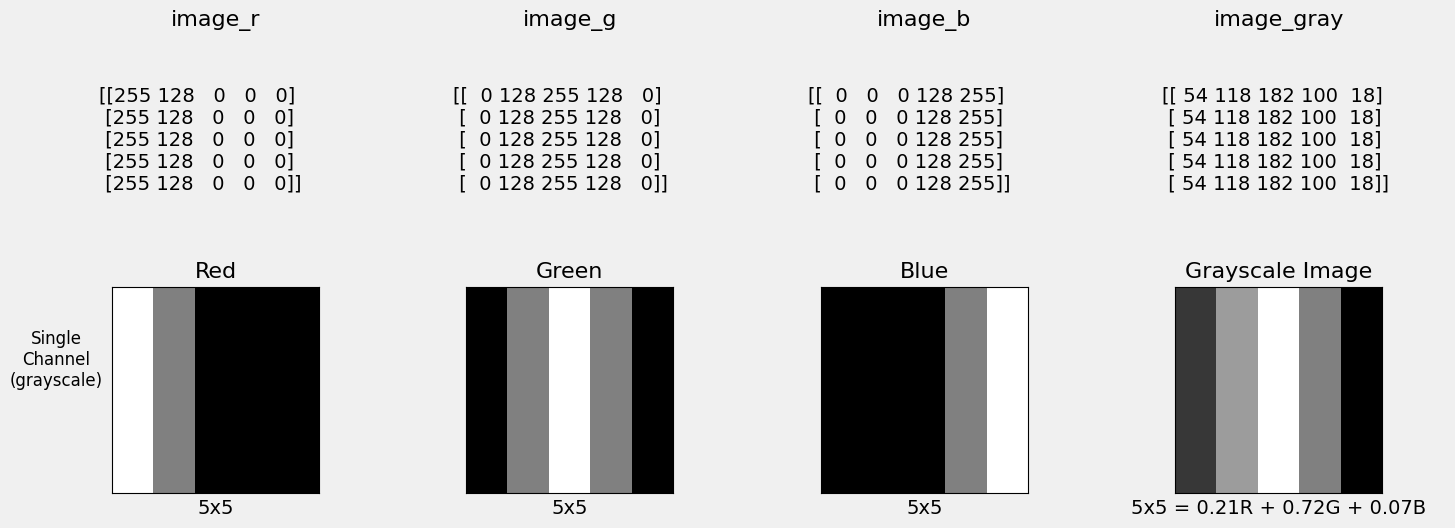

In [141]:
# 可视化灰度
fig = image_channels(image_r, image_g, image_b, image_rgb, image_gray, rows=(0, 1))

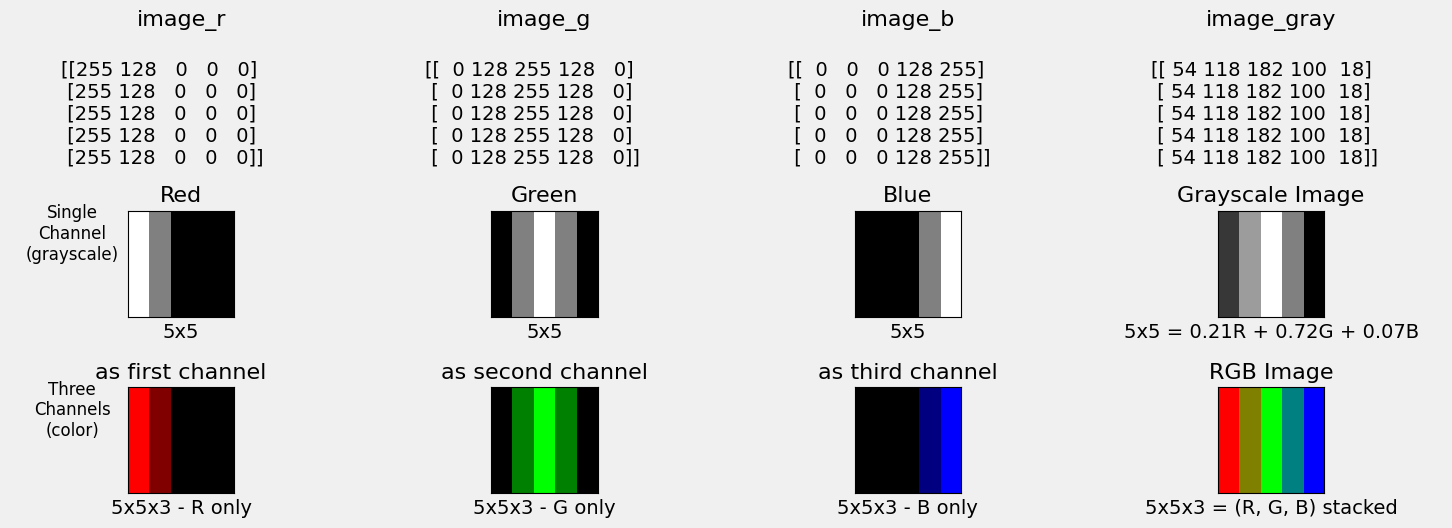

In [142]:
# 可视化三通道rgb

fig = image_channels(image_r, image_g, image_b, image_rgb, image_gray, rows=(0,1,2))

### NCHW 和 NHWC

**Q**: 解释字母的意义，它规定的对象是什么？

**Q**: 各个架构使用的不同结构是什么？（Pytorch,Tensflow,PIL）

结合代码:

**Q**: 解释shape输出的含义

**Q**: 如何转换张量的维度？


In [143]:
# 程序4-2: pytorch使用的结构和内容

print(images.shape)

example = images[7]

print(example.shape)
print(example)

(300, 1, 5, 5)
(1, 5, 5)
[[[  0 255   0   0   0]
  [  0   0 255   0   0]
  [  0   0   0 255   0]
  [  0   0   0   0 255]
  [  0   0   0   0   0]]]


In [144]:
# 程序4-3: 转置分量的位置

example_hwc = np.transpose(example, (1, 2, 0))

print(example_hwc.shape)

print(example_hwc)

(5, 5, 1)
[[[  0]
  [255]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [255]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [255]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [255]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]]]


# 然后，我要干什么？

因为涉及图像，需要大致了解`Torchvision`提供的功能，分为:
- 数据集
- 模型
- 转换
    - 基于图像
    - 基于张量
- 归一化
- 组合转换

# TorchVision

## 数据集

**Q**: 除了常见的现成数据集，`ImageFolder`是什么数据集？

## 模型

**Q**: 什么是迁移学习？


## 转换

**Q**: 转换有哪些大类？

**Q**: 数据增强是什么？不适用于什么场景？

结合代码:

**Q**: 如何将PIL形状的图像数组转为torch需要的张量？

**Q**: 数组或者说张量中分量的数值范围发生了什么变化？

**Q**: 如何将张量转为PIL图形？

In [145]:
# 程序4-4: 将HWC的Numpy数组变为CHW的张量(老方法: 注意警告)

tmp_tensorizer = ToTensor()

tmp_example_tensor = tmp_tensorizer(example_hwc)

print(tmp_example_tensor.shape)

print(tmp_example_tensor)


torch.Size([1, 5, 5])
tensor([[[0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0.]]])


D:\moreEnv\Anaconda\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [167]:
# 程序4-4-1: 将HWC的Numpy数组变为CHW的张量（新方法）

# 第一步转为chw的图像
print(example_hwc.shape,isinstance(example_hwc, torch.Tensor))

image_tensor = ToImage()(example_hwc)

print(image_tensor.shape,isinstance(image_tensor, torch.Tensor))

print(image_tensor)

# 第二步转为chw的张量

example_tensor = ToDtype(torch.float32, scale=True)(image_tensor)

print(example_tensor.shape,isinstance(example_tensor, torch.Tensor))

print(example_tensor)


(5, 5, 1) False
torch.Size([1, 5, 5]) True
Image([[[  0, 255,   0,   0,   0],
        [  0,   0, 255,   0,   0],
        [  0,   0,   0, 255,   0],
        [  0,   0,   0,   0, 255],
        [  0,   0,   0,   0,   0]]], dtype=torch.uint8, )
torch.Size([1, 5, 5]) True
Image([[[0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]]], )


In [169]:
# ps:简易方法

# 还原成example
tmp_example2 = np.transpose(example_hwc,(2, 0, 1))
print(tmp_example2.shape)

print(torch.as_tensor(tmp_example2/255).float().shape)
print(torch.as_tensor(tmp_example2/255).float())

(1, 5, 5)
torch.Size([1, 5, 5])
tensor([[[0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0.]]])


In [147]:
# 程序4-4-1: 将HWC的Numpy数组变为CHW的张量（利用组合转换合并两步)

def ToTensor():
    return Compose([ToImage(), ToDtype(torch.float32, scale=True)])

tensorizer = ToTensor()
example_tensor = tensorizer(example_hwc)

print(example_tensor.shape)
print(example_tensor)

torch.Size([1, 5, 5])
Image([[[0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]]], )


<class 'PIL.Image.Image'>


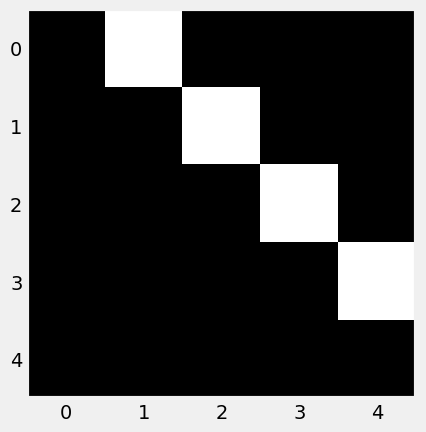

In [149]:
# 程序4-5: 张量转为hwc图片类型（注意不是numpy数组）

# 对于example_hwc的numpy数组同样生效
example_img = ToPILImage()(example_tensor)
print(type(example_img))

# 可视化结果
plt.imshow(example_img, cmap='gray')
plt.grid(False)

### 图像转换和张量转换和归一化

图像操作: `Resize`,`CenterCrop`,`GrayScale`,`RadomHorizontalFlip`,`RandomRotation`

张量操作: `LinearTransformation`,`Normalize`,`RandomEraing`,`ConvertImageDtype`


**Q**: 复习:标准化或者说归一化的作用

**Q**: `Normalize`的操作逻辑是什么？（归一化的对象是谁？）

**Q**: 为什么要标准化？神经网络的训练数据最好有什么样的特征？

**Q**: 标准化的操作和什么操作类似？



结合代码:

**Q**: `RandomHorizontalFlip`的参数是什么意思？

**Q**: 归一化的参数设置为什么要取0.5?

**Q**: 归一化的参数设置的元组形状应该和什么保持一致？




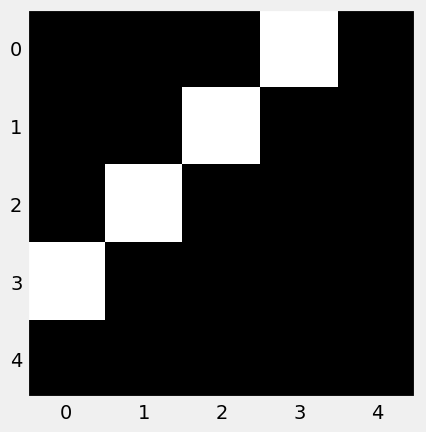

In [153]:
# 程序4-6 图像转换（水平翻转为例）

flipper = RandomHorizontalFlip(p=1)
flipped_img = flipper(example_img)

# 可视化结果
plt.imshow(flipped_img, cmap='gray')
plt.grid(False)

In [155]:
# 程序4-7 张量转换（归一化为例）

# 以翻转图像为数据，先转为张量

img_tensor = tensorizer(flipped_img)

print(img_tensor.shape)
print(img_tensor)

# 归一化
normalizer = Normalize(mean=(.5,), std=(.5,))
normalized_tensor = normalizer(img_tensor)
normalized_tensor

torch.Size([1, 5, 5])
Image([[[0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]], )


Image([[[-1., -1., -1.,  1., -1.],
        [-1., -1.,  1., -1., -1.],
        [-1.,  1., -1., -1., -1.],
        [ 1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.]]], )

### 组合转换


**Q**: 组合转换的作用？

结合代码:

**Q**: `all`函数是做什么用的？

In [157]:
# 程序4-8 组合转换

composer = Compose([RandomHorizontalFlip(p=1.0),
                    Normalize(mean=(.5,), std=(.5,))])
composed_tensor = composer(example_tensor)


# 验证结果
print((composed_tensor == normalized_tensor).all())



tensor(True)


In [162]:
# 程序4-8-1 all的使用

print((np.array([1,2,3]) == np.array([1,2,3])).all())
print((np.array([1,2,3]) == np.array([1,2,4])).all())


True
False
